Notebook to implement the tasks for Part 2 — Credit Risk & Lending ML
*   Report the exact measured default rate and the exact percentage of missing credit_bureau_score values
*   For rows with a missing bureau score add a binary is_thin_file flag
*   Split into train/test (75/25, stratified on default
*   Compute median of non-missing credit_bureau_score values using only the training split. Use it to fill missing scores in both the training and test split - 1) Encode employment_type (one-hot or label encoding, your choice in writing). 2)Scale numeric features with StandardScaler
*   Train Logistic Regression and a Decision Tree Classifier (DecisionTreeClassifier(random_state=42)) on the identical train/test split
*   Evaluate both models with a confusion matrix, accuracy, precision, recall, F1, and ROC curve + AUC, presented side by side in a comparison table.
*   Risk-based pricing table: using the logistic regression's predicted probabilities, bucket applicants into at least 4 risk tiers -  reporting the actual observed default rate within each tier to check monotonicity
*   Load txn_behaviour.csv. Select numeric behavioural features (txn_hour, is_new_device, txn_amount_inr), standardize them, and run scikit-learn's IsolationForest(random_state=42, contamination=...) with a contamination rate matching the injected anomaly proportion (15 / 265 ≈ 5.7%). Report how many of the 15 seeded anomalies were flagged as anomalous, simple recall check
*   run K-Means clustering (with the elbow method or Calinski-Harabasz index to pick k) on standardized credit_applicants.csv features to segment applicants into behavioural groups

In [1]:
# Report the exact measured default rate and the exact percentage of missing credit_bureau_score values

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

credit_app_df = pd.read_csv("credit_applicants.csv")
txn_behaviour_df = pd.read_csv("txn_behaviour.csv")
credit_app_df.head()
default_count = len(credit_app_df[credit_app_df['default'] == 1])
missing_credit_bureau_count = len(credit_app_df[credit_app_df['credit_bureau_score'].isna()])
#print("default count: ", default_count, "missing credit bureau count: ", missing_credit_bureau_count, "total count", len(credit_app_df))
print("default rate: ", f"{default_count/len(credit_app_df):.2%}")
print("percentage of missing credit_bureau_score: ", f"{missing_credit_bureau_count/len(credit_app_df):.2%}" )

default rate:  20.25%
percentage of missing credit_bureau_score:  20.00%


In [2]:
# For rows with a missing bureau score add a binary is_thin_file flag. Save it to a separate csv file "credit_applicants_thinfile.csv"

credit_app_thinflag_df = credit_app_df.copy()
credit_app_thinflag_df['is_thin_file'] = credit_app_thinflag_df['credit_bureau_score'].isna()
credit_app_thinflag_df.head()
credit_app_thinflag_df.to_csv("credit_applicants_thinfile.csv", index=False)

In [3]:
# Split into train/test (75/25, stratified on default
# Compute median of non-missing credit_bureau_score values using only training split.
# Use it to fill missing scores in both training and test split

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

features = ['age', 'monthly_income_inr', 'existing_loans_count',
 'credit_utilization_ratio', 'upi_monthly_inflow_inr',
 'bounced_payments_count', 'credit_bureau_score', 'is_thin_file', 'employment_type']
X = credit_app_thinflag_df[features].copy()
y = credit_app_thinflag_df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                stratify=y, random_state=42)
print("X_train type:", type(X_train))
print("y_train type:", type(y_train))

credit_bureau_score_median = X_train[X_train['is_thin_file'] == False]['credit_bureau_score'].median()
X_train.loc[X_train['is_thin_file'] == True, 'credit_bureau_score'] = credit_bureau_score_median
X_test.loc[X_test['is_thin_file'] == True, 'credit_bureau_score'] = credit_bureau_score_median
X_train = X_train.drop(columns=['is_thin_file'])
X_test = X_test.drop(columns=['is_thin_file'])
X_train.head()

X_train type: <class 'pandas.core.frame.DataFrame'>
y_train type: <class 'pandas.core.series.Series'>


,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,employment_type
84,28,117795,2,0.53,98652,1,582.0,self_employed
10,44,24823,1,0.33,24911,1,612.0,salaried
384,49,16828,1,0.10,67061,0,624.0,self_employed
359,39,91323,2,0.92,41891,1,808.0,gig
11,56,56975,4,0.54,106061,1,677.0,salaried


In [4]:
# 1) Encode employment_type (one-hot or label encoding, your choice in writing).
# 2) Scale numeric features with StandardScaler

numeric_features = X_train.columns.values
numeric_features = numeric_features[~np.isin(numeric_features, ['employment_type'])]
categorical_features = np.array(['employment_type'])
print(numeric_features)
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder())])
preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])

X_train_scaled = pd.DataFrame(preprocessor.fit_transform(X_train))
X_test_scaled = pd.DataFrame(preprocessor.fit_transform(X_test))
X_train_scaled.head()

['age' 'monthly_income_inr' 'existing_loans_count'
 'credit_utilization_ratio' 'upi_monthly_inflow_inr'
 'bounced_payments_count' 'credit_bureau_score']


,0,1,2,3,4,5,6,7,8,9
0,-1.145762,0.952812,0.053277,0.149735,0.995851,-0.227884,-0.148387,0.0,0.0,1.0
1,0.270945,-1.385434,-0.641639,-0.587877,-1.151228,-0.227884,0.048994,0.0,1.0,0.0
2,0.713666,-1.586508,-0.641639,-1.436132,0.076032,-1.127427,0.127947,0.0,0.0,1.0
3,-0.171776,0.287041,0.053277,1.588080,-0.656830,-0.227884,1.338550,1.0,0.0,0.0
4,1.333476,-0.576811,1.443108,0.186616,1.211575,-0.227884,0.476653,0.0,1.0,0.0


In [5]:
# Train Logistic Regression on the identical train/test split

logit = LogisticRegression(max_iter=1000, class_weight="balanced")
logit.fit(X_train_scaled, y_train)

logit_scores = logit.predict_proba(X_test_scaled)[:, 1]
logit_auc = roc_auc_score(y_test, logit_scores)
print(f"Logistic regression AUC = {logit_auc:.2f}")


Logistic regression AUC = 0.72


In [6]:
# Train Decision Tree Classifier (DecisionTreeClassifier(random_state=42)) on the identical train/test split

from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
tree.fit(X_train_scaled, y_train)

tree_scores = logit.predict_proba(X_test_scaled)[:, 1]
tree_auc = roc_auc_score(y_test, tree_scores)
print(f"Decision Tree AUC = {tree_auc:.2f}")

Decision Tree AUC = 0.72


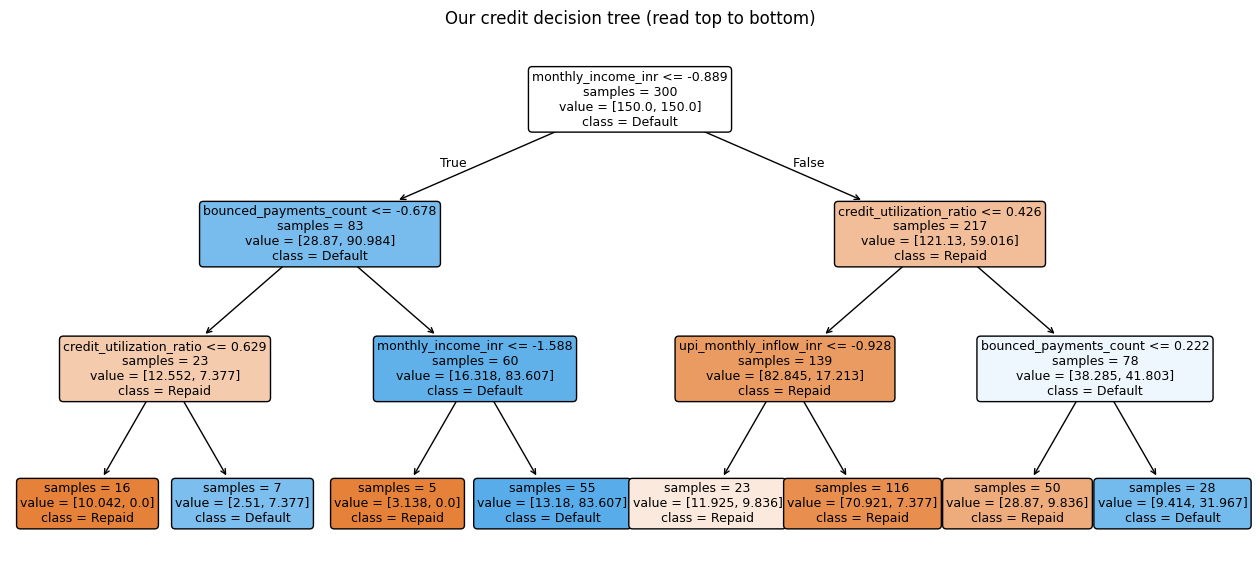

In [7]:
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(
    tree, feature_names=features, class_names=["Repaid", "Default"],
    filled=True, rounded=True, fontsize=9, impurity=False, ax=ax
)
plt.title("Our credit decision tree (read top to bottom)")
plt.show()

In [8]:
# Evaluate both models with a confusion matrix, accuracy, precision, recall, F1, and ROC curve + AUC,
# presented side by side in a comparison table. Get binary predictions for both models

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

logit_preds = logit.predict(X_test_scaled)
tree_preds = tree.predict(X_test_scaled)
print("Logistic Regression details")
display(pd.DataFrame(confusion_matrix(y_test, logit_preds), index=['Actual No Default', 'Actual Default'], columns=['Predicted No Default', 'Predicted Default']))
print("Decision Tree detais")
display(pd.DataFrame(confusion_matrix(y_test, tree_preds), index=['Actual No Default', 'Actual Default'], columns=['Predicted No Default', 'Predicted Default']))
print("Logistic Regression Classification report")
print(classification_report(y_test, logit_preds, target_names=['No Default', 'Default']))
print("Decision Tree Classification report")
print(classification_report(y_test, tree_preds, target_names=['No Default', 'Default']))

Logistic Regression details


,Predicted No Default,Predicted Default
Actual No Default,56,24
Actual Default,6,14


Decision Tree detais


,Predicted No Default,Predicted Default
Actual No Default,65,15
Actual Default,12,8


Logistic Regression Classification report
              precision    recall  f1-score   support

  No Default       0.90      0.70      0.79        80
     Default       0.37      0.70      0.48        20

    accuracy                           0.70       100
   macro avg       0.64      0.70      0.64       100
weighted avg       0.80      0.70      0.73       100

Decision Tree Classification report
              precision    recall  f1-score   support

  No Default       0.84      0.81      0.83        80
     Default       0.35      0.40      0.37        20

    accuracy                           0.73       100
   macro avg       0.60      0.61      0.60       100
weighted avg       0.74      0.73      0.74       100



In [9]:
# Calculate metrics for comparison table

# Logistic Regression metrics
logit_report = classification_report(y_test, logit_preds, output_dict=True)
#print(logit_report)
logit_accuracy = logit_report['accuracy']
logit_precision = logit_report['1']['precision']
logit_recall = logit_report['1']['recall']
logit_f1 = logit_report['1']['f1-score']

# Decision Tree metrics
tree_report = classification_report(y_test, tree_preds, output_dict=True)
tree_accuracy = tree_report['accuracy']
tree_precision = tree_report['1']['precision']
tree_recall = tree_report['1']['recall']
tree_f1 = tree_report['1']['f1-score']

# Create a comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Default)', 'Recall (Default)', 'F1-Score (Default)', 'AUC'],
    'Logistic Regression': [logit_accuracy, logit_precision, logit_recall, logit_f1, logit_auc],
    'Decision Tree': [tree_accuracy, tree_precision, tree_recall, tree_f1, tree_auc]
})

print("\n--- Model Performance Comparison ---")
display(comparison_df.set_index('Metric'))


--- Model Performance Comparison ---


,Logistic Regression,Decision Tree
Metric,,
Accuracy,0.700000,0.730000
Precision (Default),0.368421,0.347826
Recall (Default),0.700000,0.400000
F1-Score (Default),0.482759,0.372093
AUC,0.721250,0.721250


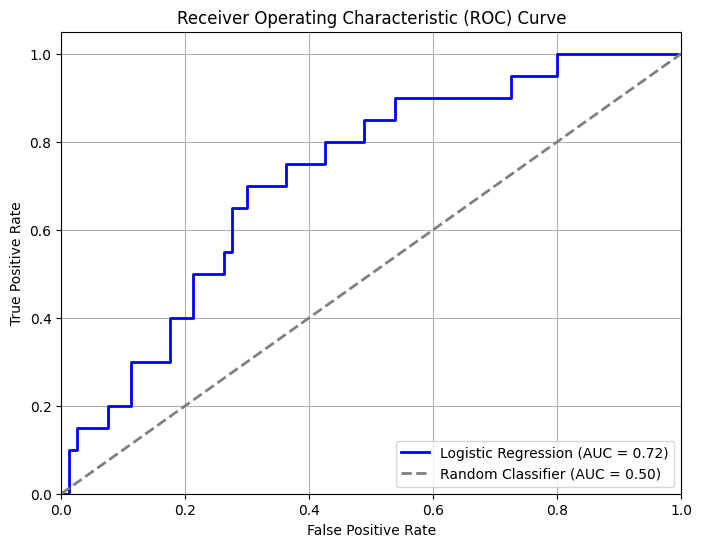

In [10]:
# Plot ROC curves
fpr_logit, tpr_logit, _ = roc_curve(y_test, logit_scores)
roc_auc_logit = auc(fpr_logit, tpr_logit)

fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_scores)
roc_auc_tree = auc(fpr_tree, tpr_tree)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logit, tpr_logit, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_logit:.2f})')
#plt.plot(fpr_tree, tpr_tree, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc_tree:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

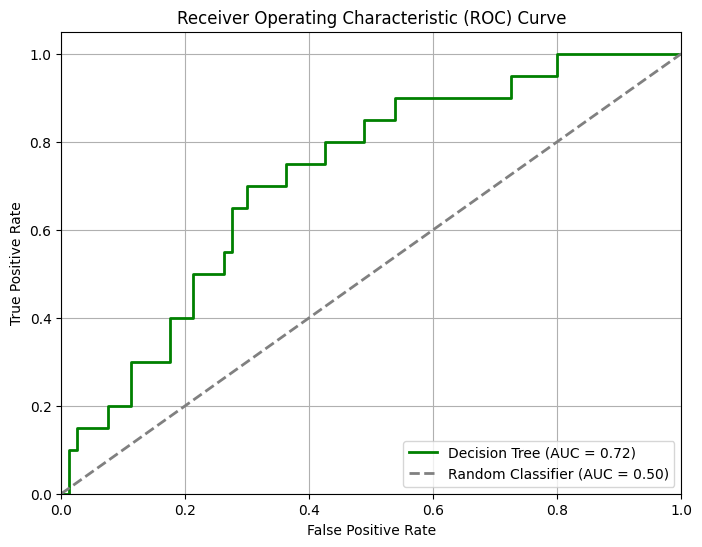

In [11]:
plt.figure(figsize=(8, 6))
#plt.plot(fpr_logit, tpr_logit, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_logit:.2f})')
plt.plot(fpr_tree, tpr_tree, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc_tree:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [51]:
# Risk-based pricing table: using the logistic regression's predicted probabilities, bucket applicants into at least 4 risk tiers -
# and assign each tier an illustrative interest-rate range in percent reporting the actual observed default rate within each tier to check monotonicity

results = X_test.copy()
results["default_probability"] = logit_scores
results["really_defaulted"] = y_test.values

#print(results[['default_probability', 'really_defaulted']].head())

# Try a few approval cut-offs and see the trade-off
for cutoff in [0.15, 0.30, 0.45, 0.60]:
    approved = results["default_probability"] < cutoff
    pct_approved = approved.mean()
    bad_in_book = results.loc[approved, "really_defaulted"].mean()
    print(f"Cut-off {cutoff:.2f}  ->  approve {pct_approved:5.1%} of people,"
          f"  defaults among approved: {bad_in_book:5.1%}")

# Simple risk-based pricing: safer borrower -> cheaper loan
def interest_rate(prob_default):
    base = 10.0           # base rate, percent
    extra = prob_default * 24.0   # up to +24% for the riskiest
    return round(base + extra, 1)

results["offered_rate_%"] = results["default_probability"].apply(interest_rate)

# Show a few example offers
show = results[["default_probability", "offered_rate_%", "really_defaulted"]].copy()
show["default_probability"] = show["default_probability"].round(2)
print()
print("Displaying a few decisons with offered rates and default rates")
print(show.head())
print(show.tail())


Cut-off 0.15  ->  approve 32.0% of people,  defaults among approved:  6.2%
Cut-off 0.30  ->  approve 47.0% of people,  defaults among approved:  8.5%
Cut-off 0.45  ->  approve 59.0% of people,  defaults among approved: 10.2%
Cut-off 0.60  ->  approve 68.0% of people,  defaults among approved: 13.2%

Displaying a few decisons with offered rates and default rates
     default_probability  offered_rate_%  really_defaulted
68                  0.01            10.3                 0
265                 0.99            33.8                 0
267                 0.22            15.2                 0
138                 0.38            19.0                 0
125                 0.06            11.4                 0
     default_probability  offered_rate_%  really_defaulted
270                 0.43            20.3                 0
292                 0.19            14.5                 0
117                 0.44            20.6                 1
119                 0.82            29.6      

In [52]:
# Load txn_behaviour.csv and do exploratory analysis

applicant_behaviour_df = pd.read_csv("txn_behaviour.csv")
print("Total txns", len(applicant_behaviour_df))
print(applicant_behaviour_df.head())

applicants = applicant_behaviour_df.groupby("applicant_id").agg(
    n_txns         = ("txn_id", "size"),
    max_amount     = ("txn_amount_inr", "max"),
    night_fraction = ("txn_hour", lambda h: (h < 6).mean()),   # share of payments before 6 AM
    device_changes = ("is_new_device", "sum"),
    p2p_fraction   = ("channel", lambda t: (t == "P2P").mean()),
).reset_index()
print(applicants.head())

Total txns 265
     txn_id applicant_id  txn_hour  is_new_device  txn_amount_inr channel
0  BTXN5000      APP1126        15              0             199     P2P
1  BTXN5001      APP1167        22              0             499     P2P
2  BTXN5002      APP1079        18              0            1999     P2P
3  BTXN5003      APP1293        18              1             999     P2M
4  BTXN5004      APP1332        12              0             199     P2P
  applicant_id  n_txns  max_amount  night_fraction  device_changes  \
0      APP1000       1         199             0.0               0   
1      APP1003       1         499             0.0               0   
2      APP1006       1         199             0.0               0   
3      APP1007       1         199             0.0               0   
4      APP1008       2         499             0.0               0   

   p2p_fraction  
0           0.0  
1           1.0  
2           1.0  
3           1.0  
4           1.0  


In [56]:
# Select numeric behavioural features (txn_hour, is_new_device, txn_amount_inr)
# standardize them and run scikit-learn's IsolationForest(random_state=42, contamination=...)
# with a contamination rate matching the injected anomaly proportion (15 / 265 ≈ 5.7%).
# Report how many of the 15 seeded anomalies were flagged as anomalous, simple recall check

from sklearn.ensemble import IsolationForest

X_behaviour = applicant_behaviour_df[['txn_hour', 'is_new_device', 'txn_amount_inr']].copy()
scaler = StandardScaler().fit(X_behaviour)
X_behaviour_scaled = scaler.transform(X_behaviour)
iso_forest = IsolationForest(random_state=42, contamination=15 / 265)
X_behaviour['anamoly_tag'] = iso_forest.fit_predict(X_behaviour_scaled)
X_behaviour["Anomaly_Score"] = iso_forest.decision_function(X_behaviour_scaled)
#print(X_behaviour[X_behaviour['anamoly_tag'] == -1].tail())

# Now finding matching indices between detected and predicted anamolies
seeded_anomalies_indices = applicant_behaviour_df[applicant_behaviour_df['txn_id'].str.startswith('BTXNA')].index
predicted_anomalies_indices = X_behaviour[X_behaviour['anamoly_tag'] == -1].index
print(seeded_anomalies_indices)
print(predicted_anomalies_indices)
correctly_flagged_anomalies = np.intersect1d(seeded_anomalies_indices, predicted_anomalies_indices)
print("Correct: ", correctly_flagged_anomalies)
#recall = len(correctly_flagged_anomalies) / len(seeded_anomalies_indices)
#print (f"Recall:  {recall:.2%} , Correctly captured {len(correctly_flagged_anomalies)} Anamolies out of {len(seeded_anomalies_indices)}")

Index([250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263,
       264],
      dtype='int64')
Index([3, 10, 81, 157, 250, 253, 254, 255, 256, 257, 258, 260, 261, 262, 263], dtype='int64')
Correct:  [250 253 254 255 256 257 258 260 261 262 263]


In [57]:
# Evaluation metrices for Isoltaion forest model output

from sklearn.metrics import precision_score, f1_score, recall_score

true_anomalies = applicant_behaviour_df['txn_id'].str.startswith('BTXNA').astype(int)
predicted_anomalies = (X_behaviour['anamoly_tag'] == -1).astype(int)
precision = precision_score(true_anomalies, predicted_anomalies)
f1 = f1_score(true_anomalies, predicted_anomalies)
recall = recall_score(true_anomalies, predicted_anomalies)
print(f"Isolation Forest Recall: {rec:.2%}")
print(f"Isolation Forest Precision: {precision:.2%}")
print(f"Isolation Forest F1-Score: {f1:.2%}")

Isolation Forest Recall: 73.33%
Isolation Forest Precision: 73.33%
Isolation Forest F1-Score: 73.33%
